# Prediction Module

    The main goal of the prediction module is to use the PropaPhenKG+ and the observations found in the detection module to cluster the observations into similar phenomenon clusters

In [103]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Libraries

### Installing

In [104]:
#!pip install pandas
#!pip install tqdm
#!pip install -U scikit-learn
#!pip install matplotlib

### Standard

In [105]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import glob

### Custom libraries

## Globals

In [106]:
path_to_kb_gazetteer = "../Detection/data/gazetteers/kbgazetteer.csv"
path_to_netwoork_gazetteer = "../Detection/data/gazetteers/world_gazetteer.csv"
path_to_observationcsv = "../Detection/data/csv/observations_phrase.csv"
path_to_worldkg_nodes = "../Description/data/worldkg_nodes.csv"

In [107]:
path_to_observations = "../data/observations/"

## Observation Embedding

    It should get the observations and the PropaPhenKG+ to transform the observations into observation vectors

### Loading Observations

In [121]:
import glob
observation_dict = {}
for file in glob.glob(path_to_observations+"*.csv"):
    source = file.split("/")[-1].replace("_Observation.csv","")
    source_prefix = '_'.join(source.split("_")[:2])
    df_observation = pd.read_csv(file)
    df_observation['System_Name'] = source_prefix+'_' + df_observation['System_Name'].astype(str)
    observation_dict[source] =  df_observation

In [124]:
def getAllObservationsFromMethod(observation_dict, method):
    df_observations = None
    for key in observation_dict.keys():
        if method in key:
            if df_observations is None:
                df_observations = observation_dict[key]
            else:
                df_observations = pd.concat([df_observations,observation_dict[key]], ignore_index=True)
    return df_observations

In [132]:
df_documentMatching = getAllObservationsFromMethod(observation_dict,"DocumentMatching")
df_paragraphMatching = getAllObservationsFromMethod(observation_dict,"ParagraphMatching")
df_sentenceMatching = getAllObservationsFromMethod(observation_dict,"SentenceMatching")

In [133]:
def obsToList(obs,isint=False):
    newlist = list([x.replace("'",'') for x in
        map(str.strip, obs.strip('][').replace('"', '').replace('"', "").split(','))])
    if isint:
        return [int(x) for x in newlist]
    else:
        return newlist

In [134]:
def getTopMax(df_observations, top=10):    
    for index, row in df_observations.iterrows():
        newsort_value = []
        newsort_names = []
        newsort_id = []
        for (x,y,z) in zip( obsToList(row['c.id']),obsToList(row['intensity'],True),obsToList(row['c.name'])):
            if z not in newsort_names:
                newsort_names.append(z)
                newsort_value.append(y)
                newsort_id.append(x)
        newsort_names = [x for _, x in sorted(zip(newsort_value, newsort_names ))]
        newsort_id = [x for _, x in sorted(zip(newsort_value, newsort_id ))]
        newsort_value.sort()
        df_observations.at[index,'c.id'] = str(newsort_id[-min(top,len(newsort_id)):])
        df_observations.at[index,'intensity'] = str(newsort_value[-min(top,len(newsort_id)):])
        df_observations.at[index,'c.name'] = str(newsort_names[-min(top,len(newsort_id)):])
    return df_observations

In [135]:
df_documentMatching = getTopMax(df_documentMatching,top=25)
df_paragraphMatching = getTopMax(df_paragraphMatching,top=25)
df_sentenceMatching = getTopMax(df_sentenceMatching,top=25)

In [12]:
obs_dict = {}
obs_set = set([])
for index, row in df_observations.iterrows():
    obs_dict[row['System_Name']] = obsToList(row['c.name'])
    obs_set = obs_set.union(set(obs_dict[row['System_Name']]))
place_set = list(obs_dict.keys())

### Embeddings

In [141]:
class ObservationBoWEmbedding():
    
    def __init__(self, df_observations):
        obs_dict = {}
        obs_set = set([])
        for index, row in df_observations.iterrows():
            obs_dict[row['System_Name']] = obsToList(row['c.name'])
            obs_set = obs_set.union(set(obs_dict[row['System_Name']]))
        place_set = list(obs_dict.keys())
        self.obs_dict = obs_dict
        self.obs_set = obs_set
        self.dict_kb = dict(zip(list(obs_set),range(len(obs_set))))
        self.dict_net = dict(zip(list(df_observations['System_Name']),range(len(place_set))))
        
    def binaryDictionaryEmbedding(self):
        obs_matrix = np.zeros((len(self.obs_dict.keys()),len(self.dict_kb)))
        for system in self.obs_dict.keys():
            for kb_item in self.obs_dict[system]:
                obs_matrix[self.dict_net[system],self.dict_kb[kb_item]] = 1
        return obs_matrix

In [150]:
documentMatchingBoW = ObservationBoWEmbedding(df_documentMatching).binaryDictionaryEmbedding()
paragraphMatchingBoW = ObservationBoWEmbedding(df_paragraphMatching).binaryDictionaryEmbedding()
sentenceMatchingBoW = ObservationBoWEmbedding(df_sentenceMatching).binaryDictionaryEmbedding()

### Connection to Neo4j

## Observation Clustering
    It should get the observation vectors and transform them into Phenomenon Cluster

In [157]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

class ObservationClustering():
    
    def __init__(self, embeddingMatrix=None):
        self.embeddingMatrix = embeddingMatrix
        
    def KMeans(self,nb_clusters,random_state=0,n_init="auto"):
        return KMeans(n_clusters=nb_clusters, random_state=random_state, n_init=n_init).fit(self.embeddingMatrix)
    
    def plot(self, legend_list, labels, apply_pca=False,apply_tsne=True, pca_random_state=1):
        if apply_pca:
            pca = PCA(2, random_state=pca_random_state)
            matrix = pca.fit_transform(self.embeddingMatrix)
        elif apply_tsne:
            tsne = TSNE(n_components=2, random_state=pca_random_state)
            matrix = tsne.fit_transform(self.embeddingMatrix)
        else:
            matrix = self.embeddingMatrix
        u_labels = np.unique(labels)
        for i in u_labels:
            plt.scatter(matrix[labels == i , 0] , matrix[labels == i , 1] , label = i)
        # Label points
        for (i,j, legend) in zip(matrix[:,0], matrix[:,1],legend_list):
            plt.text(i, j, legend)
        plt.legend()
        plt.show()
    
    def smartPrint(self, np_obslist, labels):
        u_labels = np.unique(labels)
        print('Clusters:')
        for i in range(len(u_labels)):
            print("clusters : " + str(u_labels[i]))
            print(np_obslist[labels==u_labels[i]])

In [213]:
class PredictionBenchMarkEntry():
    
    def __init__(self, name, df_observation):
        self.name = name
        self.df_observation = df_observation
        self.bowf1 = 0
        
    def BoW(self, plot=False):
        embedding = ObservationBoWEmbedding(self.df_observation).binaryDictionaryEmbedding()
        list_indexes = list(range(embedding.shape[0]))# ALL LIST
        tsne = TSNE(n_components=2, random_state=42)
        matrix = tsne.fit_transform(embedding)
        obsClusteringModule = ObservationClustering(matrix[list_indexes])
        kmeans = obsClusteringModule.KMeans(2,random_state=9)
        list_type_0 = []
        list_type_1 = []
        for index, row in self.df_observation.iterrows():
            if "COVID" in row["System_Name"]:
                list_type_1.append(0)
                list_type_0.append(1)
            else:
                list_type_1.append(1)
                list_type_0.append(0)
        list_type = list_type_1
        report = classification_report(list_type_1, kmeans.labels_, output_dict=True)
        self.bowf1 = report['weighted avg']['f1-score']
        report = classification_report(list_type_0, kmeans.labels_, output_dict=True)
        if(self.bowf1 < report['weighted avg']['f1-score']):
            self.bowf1 = report['weighted avg']['f1-score']
            list_type = list_type_0
        if plot:
            obsClusteringModule.plot(np.array(list_type),kmeans.labels_,
                         apply_tsne=False )

In [214]:
documentEntry = PredictionBenchMarkEntry("Document Matching",df_documentMatching)
paragraphEntry = PredictionBenchMarkEntry("Paragraph Matching",df_paragraphMatching)
sentenceEntry = PredictionBenchMarkEntry("Sentence Matching",df_sentenceMatching)

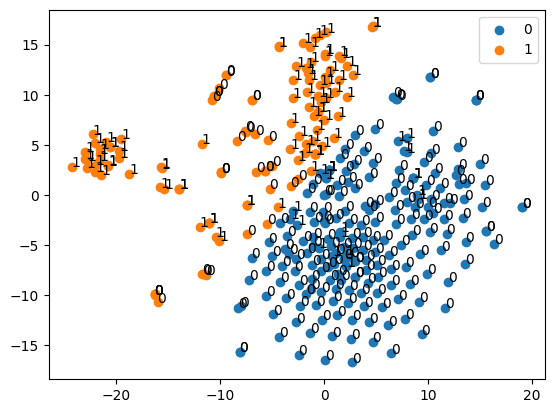

F1-Score of 0.8145934630677729


In [217]:
documentEntry.BoW(True)
print("F1-Score of " + str(documentEntry.bowf1))

/data/dataRapide/gabriel/git/DDPF/Prediction/prvenv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/data/dataRapide/gabriel/git/DDPF/Prediction/prvenv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/data/dataRapide/gabriel/git/DDPF/Prediction/prvenv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

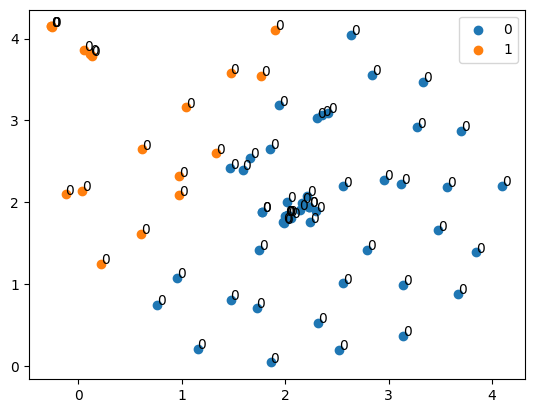

F1-Score of 0.8548387096774194


In [218]:
paragraphEntry.BoW(True)
print("F1-Score of " + str(paragraphEntry.bowf1))

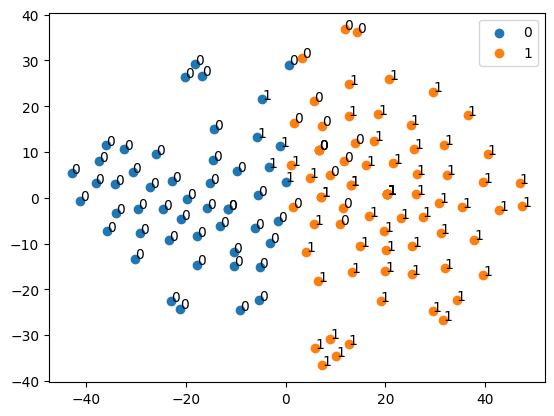

F1-Score of 0.8396439241509664


In [219]:
sentenceEntry.BoW(True)
print("F1-Score of " + str(sentenceEntry.bowf1))

## W.H.O. Confirmed Observations

In [220]:
import sys
sys.path.append('../Detection/')
from lib.kgce.schema.semantic.neo4jclasses import Neo4jRelation
from lib.kgce.neo4j.handler import Neo4jWrapper

In [221]:
from neo4j import GraphDatabase
from tqdm import tqdm


class Neo4jWrapper:

    def __init__(self, uri, userName, password):
        self.uri = uri
        self.userName = userName
        self.password = password
        # Connect to the neo4j database server
        self.graphDB_Driver  = GraphDatabase.driver(uri, auth=(userName, password)) 
        
    def sendQuery(self, cql_commands):
        result = []
        done_queries = []
        with self.graphDB_Driver.session() as graphDB_Session:
            for cqlCreate in tqdm(cql_commands):
                try:
                    result += [graphDB_Session.run(cqlCreate).to_df()]
                    done_queries.append(cqlCreate)
                except Exception as e:
                    tqdm.write(str(e))
                    tqdm.write(cqlCreate)
                    result += [str(e)]
        return result
    
    def closeConnection(self):
        self.graphDB_Driver.close()

In [238]:
def getTrueIndexes(phenomenonSourceName, date,df_observations,df_result):
    jm = df_observations[
    df_observations['System_Name'].str.contains(phenomenonSourceName)]
    jm = jm[jm["n.id"].isin(df_result[df_result["Date"]==date]['Country'].tolist())]
    return jm.index.tolist()

In [34]:
neowrapper = Neo4jWrapper(uri="bolt://localhost:7687",userName="neo4j",password="test")

In [223]:
jm = df_sentenceMatching[
    df_sentenceMatching['System_Name'].str.contains("Journal_COVID")]

In [225]:
jm

,Unnamed: 0,System_Name,n.id,c.name,c.id,intensity
0,0,"Journal_COVID_""China""",wkg:424313582,"['host', 'year', 'Coronavirus', 'Genus: Corona...","['A18644523', 'A8317452', 'A0002206', 'A119943...","[5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, ..."
1,1,"Journal_COVID_""India""",wkg:424314145,"['reactive', 'state', 'well', 'according', 'an...","['A8323612', 'C0205332', 'C1551397', 'A0135100...","[5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 8, ..."
2,2,"Journal_COVID_""Singapore""",wkg:531668011,"['antibodies', 'study', 'bats']","['A18569647', 'A18675045', 'A18590538']","[5, 5, 6]"
3,3,"Journal_COVID_""United States""",wkg:424317935,"['University', 'news']","['A18580982', 'A2887795']","[5, 5]"


In [239]:
strQuery = """MATCH (b:CUI)-[r:isReported]->(c:Country) WHERE b.id = "C0276180" return c.id as Country, r.date as Date;"""
result = neowrapper.sendQuery([strQuery])
df_result_mnokey = result[0]
df_result_mnokey["Date"] = df_result_mnokey["Date"].apply(lambda x: x[:7].lower())
df_result_mnokey = df_result_mnokey.drop_duplicates()

100%|█████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.21s/it]


In [401]:
monkeyindex = getTrueIndexes(
    'Journal_Monkeypox','2022-05',df_documentMatching,df_result_mnokey) + getTrueIndexes(
    'Medical_Monkeypox','2022-06',df_documentMatching,df_result_mnokey) + getTrueIndexes(
    'Social_Monkeypox','2022-05',df_documentMatching,df_result_mnokey)

In [402]:
len(monkeyindex)

34

In [242]:
# Run only once
strQueryChinaNov = """MATCH (startNode:CUI {id: 'C5203670'}), (endNode:Country {id:'wkg:424313582'})
Create (startNode)-[relation:isReported]->(endNode)
 SET relation.date = '2019-11' """
strQueryChinaDec = """MATCH (startNode:CUI {id: 'C5203670'}), (endNode:Country {id:'wkg:424313582'})
Create (startNode)-[relation:isReported]->(endNode)
 SET relation.date = '2019-12' """
result = neowrapper.sendQuery([strQueryChinaNov,strQueryChinaDec])

100%|█████████████████████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.75s/it]


In [243]:
strQuery = """MATCH (b:CUI)-[r:isReported]->(c:Country) WHERE b.id = "C5203670" return c.id as Country, r.date as Date;"""
result = neowrapper.sendQuery([strQuery])
df_result_covid = result[0]
df_result_covid["Date"] = df_result_covid["Date"].apply(lambda x: x[:7].lower())
df_result_covid = df_result_covid.drop_duplicates()

100%|█████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.66it/s]


In [244]:
df_result_covid

,Country,Date
0,wkg:424297917,2024-03
1,wkg:424297917,2024-02
5,wkg:424297917,2024-01
9,wkg:424297917,2023-12
14,wkg:424297917,2023-11
...,...,...
18833,wkg:424313734,2020-07
18837,wkg:424313734,2020-06
18841,wkg:424313734,2020-05
18846,wkg:424313734,2020-04


In [403]:
covidindex = getTrueIndexes(
    'Journal_COVID','2019-11',df_documentMatching,df_result_covid) + getTrueIndexes(
    'Medical_COVID','2019-12',df_documentMatching,df_result_covid) + getTrueIndexes(
    'Social_COVID','2020-02',df_documentMatching,df_result_covid)

In [404]:
list_indexes = monkeyindex + covidindex

In [405]:
len(list_indexes)

54

In [406]:
list_indexes

[303,
 304,
 306,
 308,
 309,
 311,
 317,
 318,
 321,
 329,
 330,
 331,
 335,
 215,
 216,
 218,
 220,
 226,
 233,
 236,
 243,
 249,
 250,
 251,
 253,
 255,
 263,
 264,
 274,
 277,
 290,
 292,
 293,
 294,
 4,
 160,
 33,
 42,
 48,
 59,
 64,
 67,
 75,
 78,
 81,
 82,
 84,
 91,
 111,
 132,
 133,
 135,
 139,
 149]

In [418]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=15)
embeddingMatrix = ObservationBoWEmbedding(df_documentMatching).binaryDictionaryEmbedding()
matrix = tsne.fit_transform(embeddingMatrix)
obsClusteringModule = ObservationClustering(matrix[list_indexes])

In [419]:
kmeans = obsClusteringModule.KMeans(2,random_state=15)

In [423]:
list_type = []
for index, row in df_documentMatching.iterrows():
    if index in monkeyindex:
        list_type.append(1)
    elif index in covidindex:
        list_type.append(0)

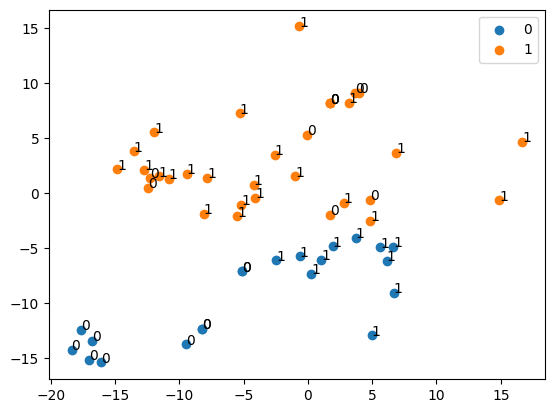

In [424]:
obsClusteringModule.plot(np.array(list_type),kmeans.labels_,
                         apply_tsne=False )

In [425]:
from sklearn.metrics import f1_score
print(classification_report(list_type, kmeans.labels_))

              precision    recall  f1-score   support

           0       0.48      0.50      0.49        20
           1       0.70      0.68      0.69        34

    accuracy                           0.61        54
   macro avg       0.59      0.59      0.59        54
weighted avg       0.62      0.61      0.61        54

